# Training

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import torch.nn as nn
import matplotlib.pyplot as plt
import scipy.signal as signal
from torch.optim import Adam, AdamW

from tqdm import tqdm

from Transformer.Noise import Noise
from Transformer.Model1D import DiT1D

device = "cuda"


from logger import logger

log = logger("1D DiT")

2025/05/02 19:42:52 INFO mlflow.tracking.fluent: Experiment with name '1D DiT' does not exist. Creating a new experiment.


In [2]:




## PARAMETERS

LABEL = "S_norm"
SIGNAL_LENGTH = 256
T = 300
BETA_START = 0.00001
BETA_END = 0.02
PATCH_SIZE = 4
EMBED_DIM = 256
HIDDEN_DIM = 256
LR = 0.0001
EPOCHS = 50

params = {
    "Label": LABEL,
    "Signal Length": SIGNAL_LENGTH,
    "T": T,
    "Beta Start": BETA_START,
    "Beta End": BETA_END,
    "Patch Size": PATCH_SIZE,
    "Embedding Dimension": EMBED_DIM,
    "Hidden Dimension": HIDDEN_DIM,
    "Learning Rate": LR,
    "Epochs": EPOCHS,
    "Optimizer" : "AdamW"
}
log.log_param(params)

In [3]:
def return_samples(LABEL, data):
    index = {"F_norm": [a for a in range(417,712)],
             "N_norm": [a for a in range(2,1002)],
             "Q_norm": [a for a in range(46,1133)],
             "S_norm": [a for a in range(1953, 2721)],
             "V_norm": [a for a in range(854, 1295)]}
    
    y = data[index[LABEL]]
    # y = y.reshape(y.shape[0], 1, y.shape[-1])
    
    return y

def batching(a, n):
    n = min(n, len(a))
    k, m = divmod(len(a), n)
    
    return (a[i*k+min(i, m):(i+1)*k+min(i+1, m)] for i in range(n))


def loader(label, batch_size, resample):
    data = pd.read_pickle("./data/"+label+".pkl")
    
    X = np.array(data["beat"].to_list())
    X = signal.resample(X, resample, axis=1)
    X = return_samples(label, X)
    n = len(X) // batch_size 
    a = range(n*batch_size)
    # n = int(len(data)/batch_size)-1
    
    batches = list(batching(a, n))
    X = torch.Tensor(X)
    # X = torch.cat([X, torch.zeros((X.shape[0], 512-X.shape[1]))], dim=1)
    
    return X, batches

def augment_image(data, batches):
    images = []
    for b in range(len(batches)):
        tmp = data[batches[b]]
        if tmp.shape == data[batches[0]].shape:
            tmp = tmp.unsqueeze(0)
            images.append(tmp)
    
    return images

def vis(signals):
    plt.plot(signals.squeeze(1).transpose(0,1))

torch.Size([768, 1, 256])


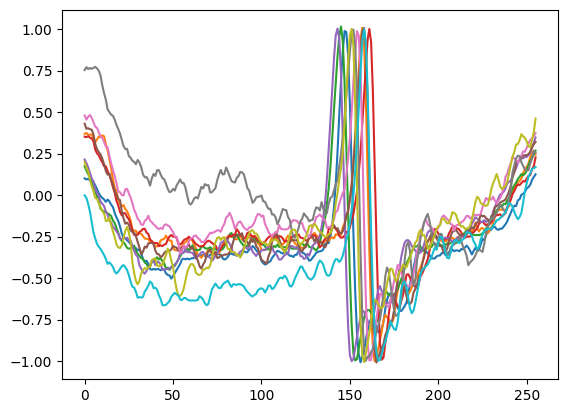

In [4]:
data, batches = loader(LABEL, 128,SIGNAL_LENGTH)
data= data.unsqueeze(1)
print(data.shape)


# images = torch.stack(augment_image(data, batches),dim=0)
# images = images[:64,:,:,:]
# print(images.shape)
batch_size = 16
batches = list(batching(range(len(data)), int(len(data)/batch_size)+1))
vis(data[batches[0]][:10])
plt.show()



# plt.imshow(data[batches[1]])


# # data = augment_image(data, batches)


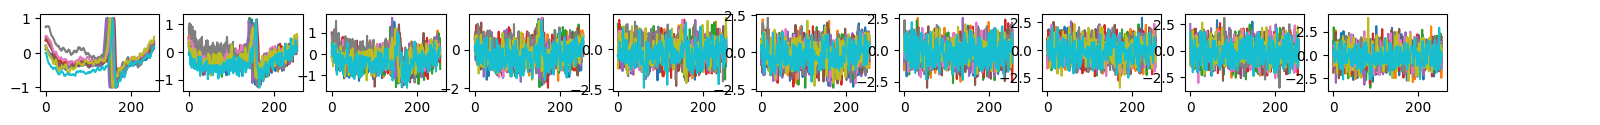

In [5]:

obj = Noise(T, start=BETA_START, end = BETA_END)


plt.figure(figsize=(20,1))
plt.axis('off')
num_images = 10
stepsize = int(T/num_images)

for idx in range(0, T, stepsize):
    t = torch.Tensor([idx]).type(torch.int64)
    plt.subplot(1, num_images+1, int(idx/stepsize) + 1)
    img, noise = obj.forward_diffusion_sample(data[batches[0]][:10].squeeze(0), t)
    plt.plot(img.cpu().squeeze(1).transpose(0,1))

In [6]:

model = DiT1D(patch_size=PATCH_SIZE, signal_length = SIGNAL_LENGTH, embed_dim = EMBED_DIM,  hidden_dim=HIDDEN_DIM)
print("Num params: ", sum(p.numel() for p in model.parameters()))

Num params:  6606596


In [7]:
def get_loss(model, x_0, t):
    x_noisy, noise = obj.forward_diffusion_sample(x_0, t, device)
    noise_pred = model(x_noisy, t)
    return F.mse_loss(noise, noise_pred)

In [8]:
@torch.no_grad()
def sample_timestep(x, t):

    betas_t = obj.get_index_from_list(obj.betas, t, x.shape)
    sqrt_one_minus_alphas_cumprod_t = obj.get_index_from_list(obj.sqrt_one_minus_alphas_cumprod, t, x.shape)
    sqrt_recip_alphas_t = obj.get_index_from_list(obj.sqrt_recip_alphas, t, x.shape)
    
    pred = model(x, t)
    mu = sqrt_recip_alphas_t * (x - betas_t * pred / sqrt_one_minus_alphas_cumprod_t)
    posterior_variance_t = obj.get_index_from_list(obj.posterior_variance, t, x.shape)
    
    if t == 0:
        return mu
    else:
        noise = torch.randn_like(x)
        return mu + torch.sqrt(posterior_variance_t) * noise 

@torch.no_grad()
def sample_plot_image():
    img = torch.randn((16, 1, 256), device=device)
    plt.figure(figsize=(20,1))
    plt.axis('off')
    num_images = 10
    stepsize = int(T/num_images)

    for i in range(0,T)[::-1]:
        t = torch.full((1,), i, device=device, dtype=torch.long)
        img = sample_timestep(img, t)

        img = torch.clamp(img, -1.0, 1.0)
        if i % stepsize == 0:
            plt.subplot(1, num_images, int(i/stepsize)+1)
            plt.plot(img.detach().cpu()[0].squeeze(0))
    plt.show()
    return img         

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 0 | Loss: 0.2219502329826355 


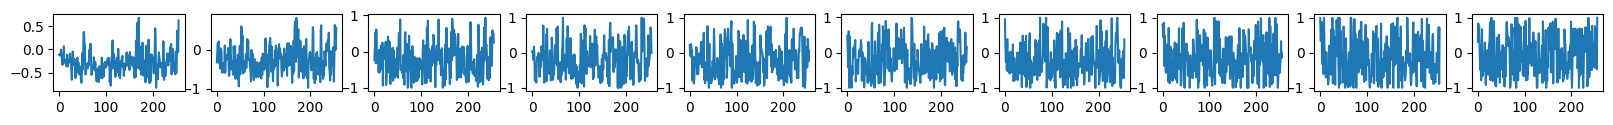

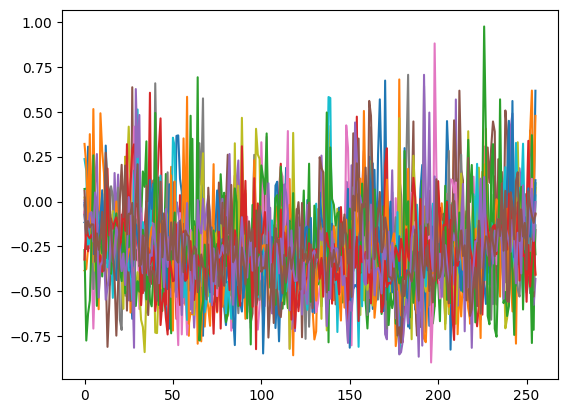

100%|██████████| 50/50 [01:01<00:00,  1.23s/it]


In [9]:


device = "cuda"
model.to(device)
optimizer = AdamW(model.parameters(), lr=LR)
epochs = EPOCHS


loss_curve = []

for epoch in tqdm(range(epochs)):
    np.random.shuffle(batches)
    for b in batches:
        optimizer.zero_grad()

        t = torch.randint(0, T, (1,), device=device).long()
        
        loss = get_loss(model, data[b], t)
        loss_curve.append(loss.detach().cpu())
        loss.backward()
        optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item()} ")
        pred_img = sample_plot_image()
        vis(pred_img.detach().cpu())
        plt.show()

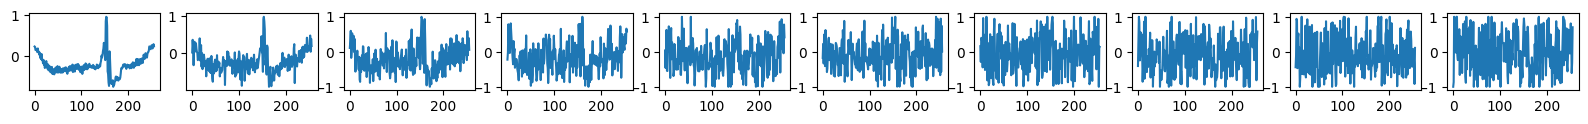

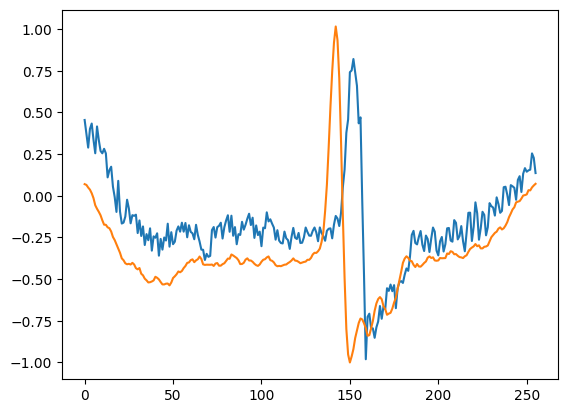

In [10]:
def rescale_tensor(x, new_min, new_max):
    current_min = x.min()
    current_max = x.max()

    normalized_x = (x - current_min) / (current_max - current_min)
    
    rescaled_x = normalized_x * (new_max - new_min) + new_min
    return rescaled_x



pred_img = sample_plot_image()
pred_img = rescale_tensor(pred_img, -1 , 1)
vis(pred_img[4].detach().cpu())
c1 = np.random.randint(len(batches))
plt.plot(data.detach().cpu()[batches[c1][0]].transpose(0,1))
plt.show()

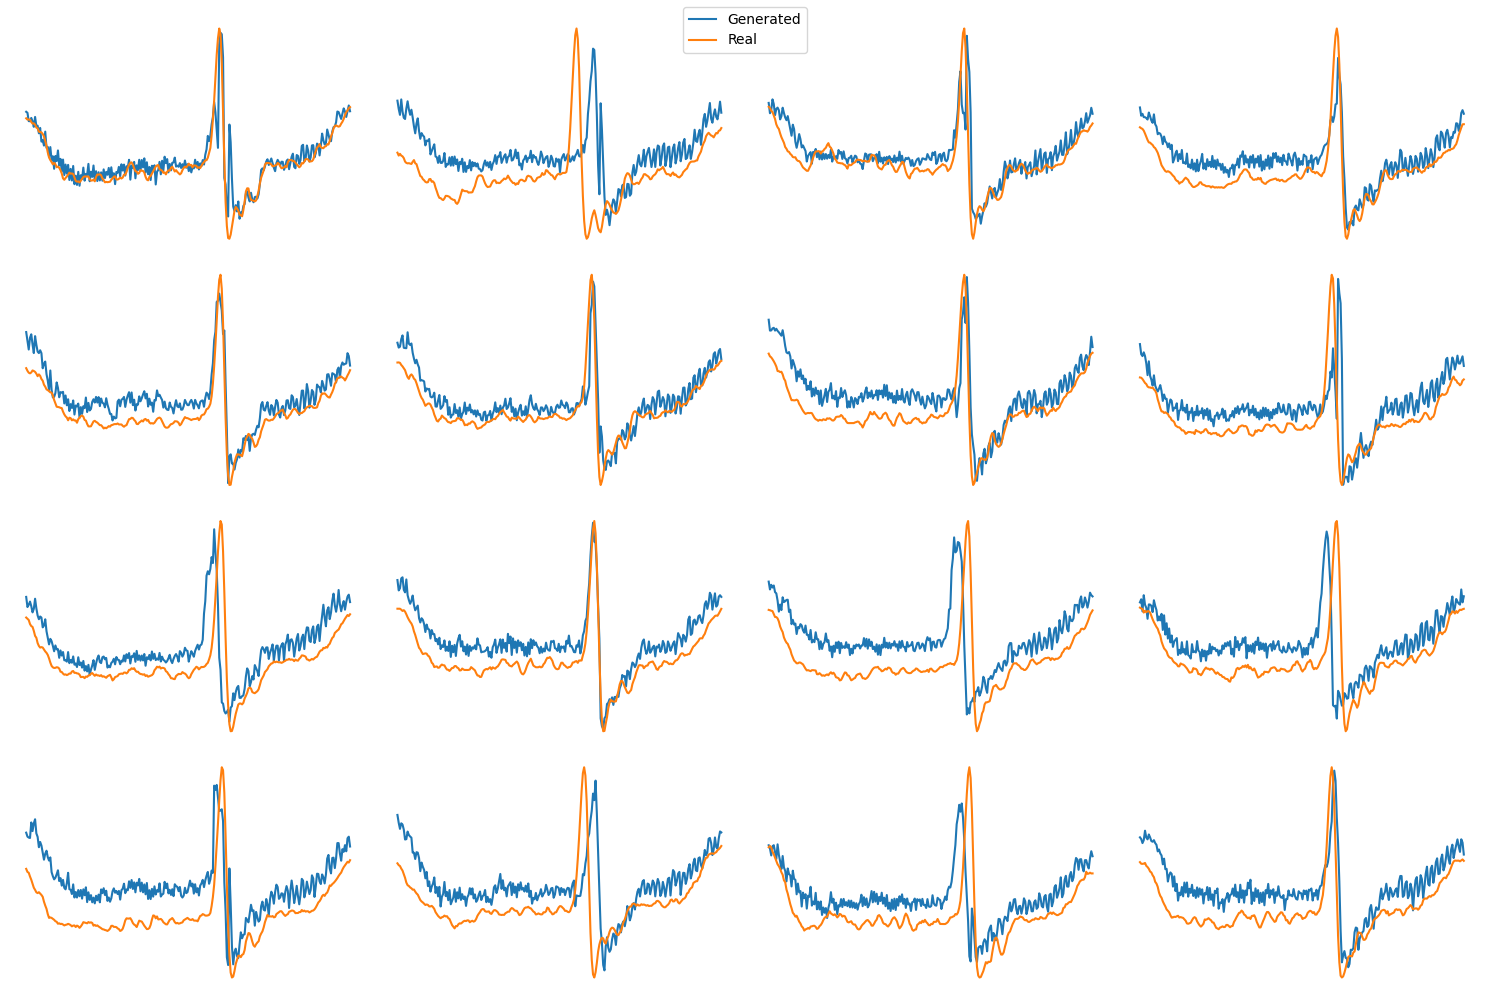

In [11]:
# save some signals
pred_img = pred_img.detach().cpu()
torch.save(pred_img, "./Transformer/"+ LABEL[0]+"_1d.pt")


n = int(np.ceil(np.sqrt(pred_img.shape[0])))
fig, axes = plt.subplots(n, n, figsize=(15, 10))
axes = axes.flatten()
c1 = np.random.randint(len(batches))

for i,signal in enumerate(pred_img):
    axes[i].plot(signal.transpose(0,1), label="Generated")
    axes[i].plot(data.detach().cpu()[batches[c1][i]].transpose(0,1), label="Real")
    axes[i].grid(False)
    axes[i].axis('off')
    
plt.tight_layout()
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center')
plt.savefig("./Transformer/"+ LABEL[0]+"_1d.png")
plt.show()

In [12]:
# save model weights

path = './weights/dit/weights.pth'
torch.save(model.state_dict(), path)

# Metrics

In [13]:
# getting metrics

from Metrics.metrics import *
from Metrics.utils import utility
from tslearn.metrics import SoftDTWLossPyTorch
from collections import defaultdict

import pandas as pd
import numpy as np
import torch
import scipy.signal as signal
import matplotlib.pyplot as plt

from dtw import dtw


Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



c:\Users\adity\anaconda3\envs\mlflow\lib\site-packages\tslearn\bases\bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


In [14]:
class pipeline:
    def __init__(self, metric_size):
        self.utils = utility()
        self.dtw = SoftDTWLossPyTorch(gamma=0.01)
        self.metric_size = metric_size
        
    def process(self, input, samples):
        # Convert images once, not repeatedly
        input_imgs = self.utils.convert(input.squeeze(1))
        sample_imgs = self.utils.convert(samples.squeeze(1))

        batch_size, sample_size = input_imgs.shape[0], sample_imgs.shape[0]
        
        # Pre-allocate metrics tensor
        metrics = torch.zeros((batch_size, self.metric_size, sample_size), device=input.device)
        
        # Vectorize outer loop
        for s in range(sample_size):
            grayB = sample_imgs[s]  # Shared across batch
            # sigB = samples[s].reshape(1, -1, 1)  # Shared across batch
            sigB = samples[s]
            
            # Parallelize batch computation
            grayA = input_imgs  # All input images
            # sigA = input.reshape(batch_size, -1, 1)  # All input signals
            sigA = input
            
            # Precompute DTW for the entire batch
            # dtw_values = torch.stack([self.dtw(sigA[b].reshape(1,-1,1), sigB) for b in range(batch_size)])
            tmp = []
            for b in range(batch_size):
                align = dtw(sigA[b], sigB, dist_method='euclidean')
                tmp.append(torch.tensor(align.distance))
            dtw_values = torch.stack(tmp)
            
            # Compute all metrics for the batch
            metric_results = torch.stack([torch.tensor([UQI.process(grayA[b], grayB),
                                          VIFP.process(grayA[b], grayB),
                                          SCC.process(grayA[b], grayB),
                                          SAM.process(grayA[b], grayB),
                                          ERGAS.process(grayA[b], grayB),
                                          RASE.process(grayA[b], grayB),
                                          SIFT.process(grayA[b], grayB),
                                          SSIM.process(grayA[b], grayB),
                                          dtw_values[b]]) for b in range(batch_size)], dim=0)
            
            metrics[:, :, s] = metric_results

        # Take the mean across the sample dimension
        # metrics = metrics.mean(dim=2)
        return metrics
    
pip = pipeline(9)

In [15]:
# REAL DATA TO BE COMPARED WITH
REAL = data[np.random.randint(low = 0,high=data.shape[0], size=4)]


# Load real and generated Q signals => Transformers 1d

# a = data[np.random.randint(low = 0,high=data.shape[0], size=4)]
gen = torch.load("./Transformer/"+LABEL[0]+"_1d.pt")


# # visualize these signals

# plt.figure()
# plt.plot(a.squeeze(1).transpose(0,1))
# plt.plot(b.squeeze(1).transpose(0,1))
# plt.savefig("tmp.png")

# metrics = pip.process(a,b)

summ = defaultdict(list)
for j in range(4):
    # a = data[np.random.randint(low = 0, high = data.shape[0], size = 4)]
    b = gen[(j*4):(4 + j*4)]
    
    metrics = pip.process(REAL,b)
    summ["UQI"] += torch.Tensor.tolist(metrics[:,0].reshape(1,-1))[0]
    summ["VIFP"] += torch.Tensor.tolist(metrics[:,1].reshape(1,-1))[0]
    summ["SCC"] += torch.Tensor.tolist(metrics[:,2].reshape(1,-1))[0]
    summ["SAM"] += torch.Tensor.tolist(metrics[:,3].reshape(1,-1))[0]
    summ["ERGAS"] += torch.Tensor.tolist(metrics[:,4].reshape(1,-1))[0]
    summ["RASE"] += torch.Tensor.tolist(metrics[:,5].reshape(1,-1))[0]
    summ["SIFT"] += torch.Tensor.tolist(metrics[:,6].reshape(1,-1))[0]
    summ["SSIM"] += torch.Tensor.tolist(metrics[:,7].reshape(1,-1))[0]
    summ["DTW"] += torch.Tensor.tolist(metrics[:,8].reshape(1,-1))[0]

summ = pd.DataFrame(summ)
print("Metrics of Transformer 1d generated signals")
print(summ.mean())

log.log_metrics(summ.mean().to_dict())

print(summ.min())
print(summ.max())

Metrics of Transformer 1d generated signals
UQI        0.984758
VIFP       0.014860
SCC        0.000079
SAM        0.123794
ERGAS      3.095205
RASE     273.627131
SIFT      11.796875
SSIM       0.905115
DTW       28.276294
dtype: float64
UQI        0.980944
VIFP       0.000475
SCC       -0.003608
SAM        0.107249
ERGAS      2.683053
RASE     211.355789
SIFT       2.000000
SSIM       0.887141
DTW       13.423995
dtype: float64
UQI        0.988515
VIFP       0.104839
SCC        0.006039
SAM        0.137341
ERGAS      3.432174
RASE     325.689240
SIFT      28.000000
SSIM       0.929038
DTW       50.357761
dtype: float64


In [16]:
# artifact

log.create_artifacts(["Training Info 1","v1"], data, pred_img, model)

2025/05/02 19:44:52 WARNING mlflow.models.signature: Failed to infer schema for inputs. Setting schema to `Schema([ColSpec(type=AnyType())]` as default. Note that MLflow doesn't validate data types during inference for AnyType. To see the full traceback, set logging level to DEBUG.
2025/05/02 19:44:52 WARNING mlflow.models.signature: Failed to infer schema for outputs. Setting schema to `Schema([ColSpec(type=AnyType())]` as default. To see the full traceback, set logging level to DEBUG.
2025/05/02 19:44:52 WARNING mlflow.utils.requirements_utils: Found torch version (2.7.0+cu118) contains a local version label (+cu118). MLflow logged a pip requirement for this package as 'torch==2.7.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2025/05/02 19:44:58 WARNING mlflow.utils.requirements_utils: Found torch version (2.7.0+cu118) contains a local version label (+cu11